## Diffeomorphic Bases Radial

Here, we do the diffeomorphic pullback operator on radial domains which are supposedly more stable:

In [1]:
%load_ext autoreload
import torch
import numpy as np
import matplotlib.pyplot as plt
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float64)


Visualize the vector field:



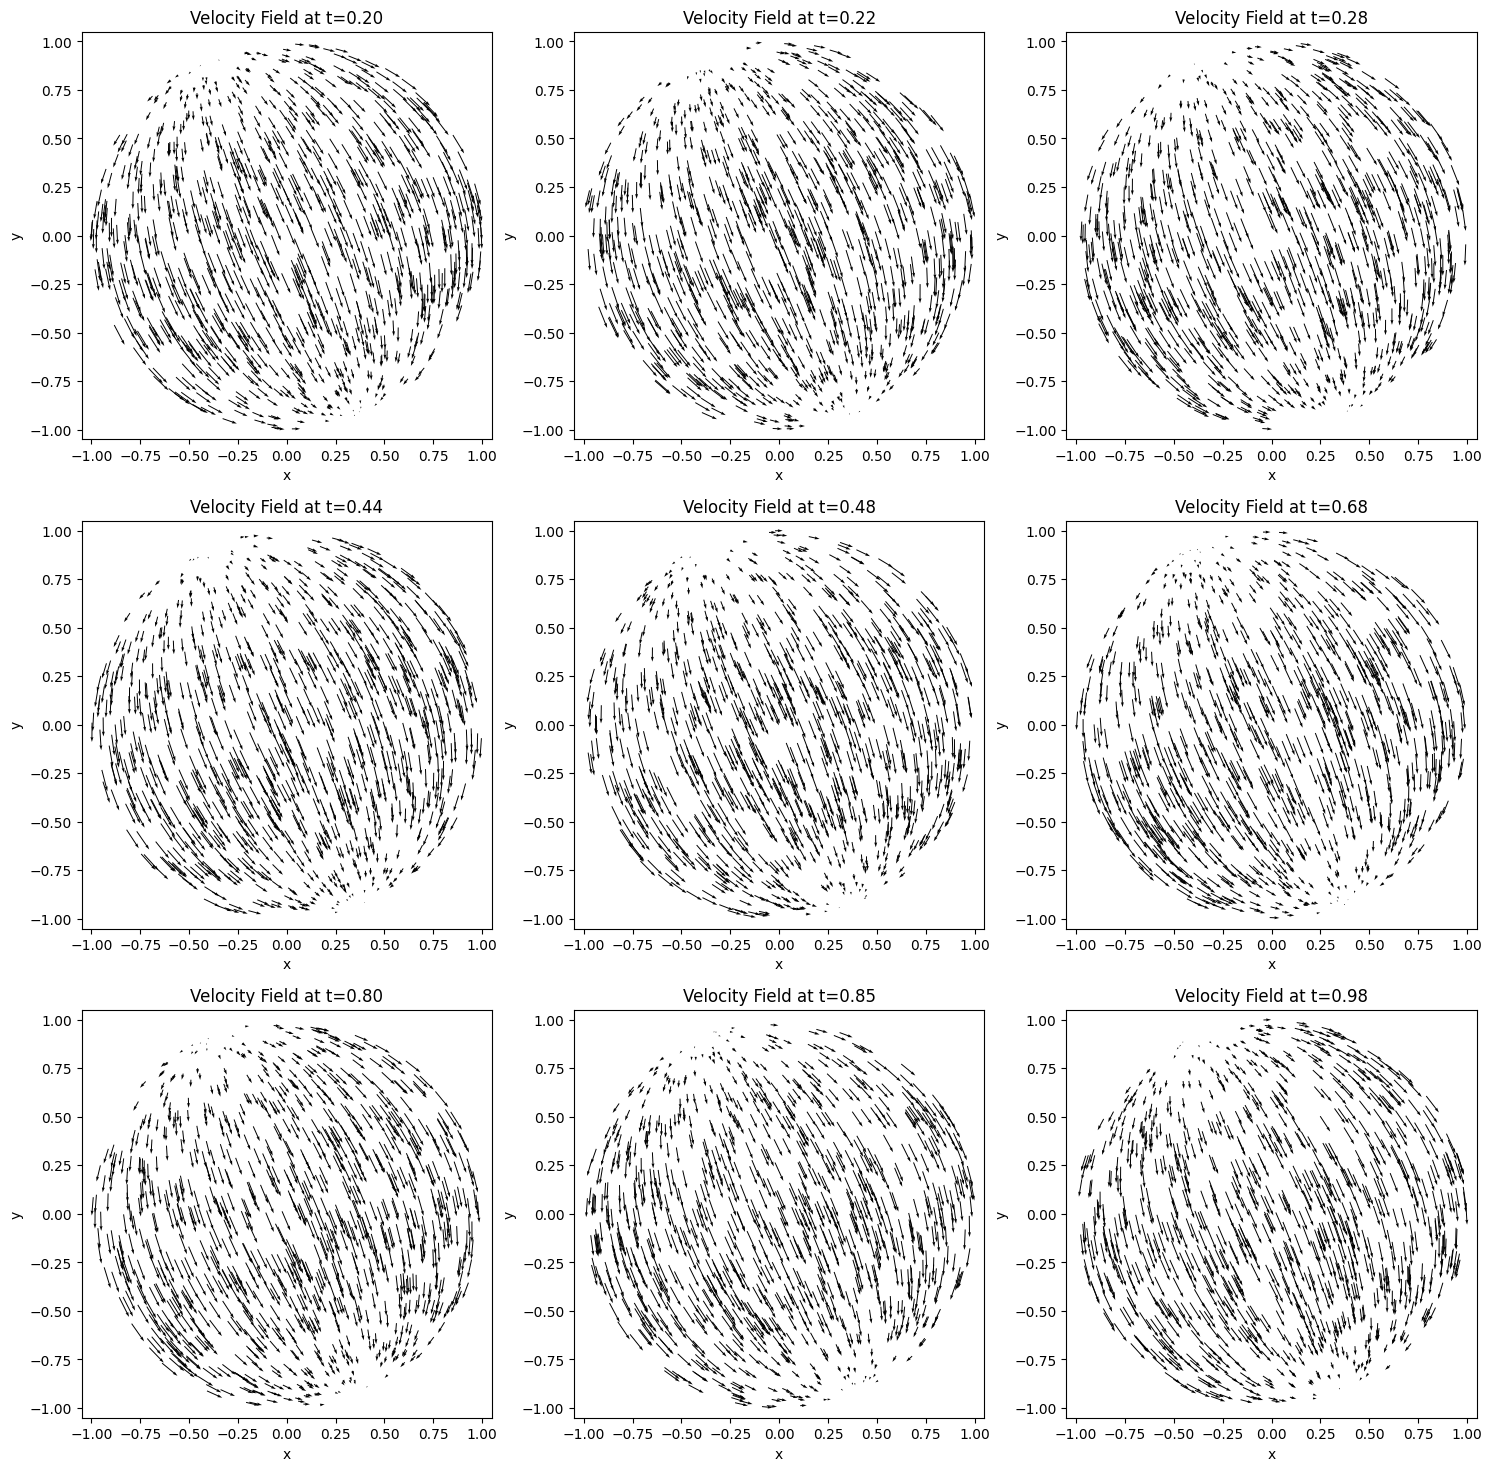

In [2]:
%autoreload 2
from half_densities.diffeomorphisms.continuous_time import CTRadialFlow
from half_densities.utils import polar_to_cartesian, sample_uniform_disk

torch.manual_seed(0)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18,18))
N = 1000
T = CTRadialFlow(
    dimensions=2,
    gamma = 1.,
    # normalize_velocity=True,
).to(device)
viz_magnitude = 10.0

rtheta = sample_uniform_disk(9 * N).to(device)
xy = polar_to_cartesian(rtheta)  # shape (9*N, 2)

# sample 9 random times in [0,1]
t = torch.rand(9).to(device)
# sort t for better visualization
t, _ = torch.sort(t)
# repeat t for each point
t = torch.repeat_interleave(t, N)
v =  viz_magnitude * T.velocity_field(t, xy)
# transform v to cartesian coordinates


for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        idx = row * 3 + col
        ax.quiver(xy[idx * N:(idx + 1) * N,0].detach().cpu(), xy[idx * N:(idx + 1) * N,1].detach().cpu(),
                  v[idx * N:(idx + 1) * N,0].detach().cpu(), v[idx * N:(idx + 1) * N,1].detach().cpu(),
                  angles='xy', scale_units='xy', scale=10.0, alpha=1)
        ax.set_title(f'Velocity Field at t={t[idx * N].item():.2f}')
        ax.set_xlim(-1.05,1.05)
        ax.set_ylim(-1.05,1.05)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()

Apply the pullback operator:

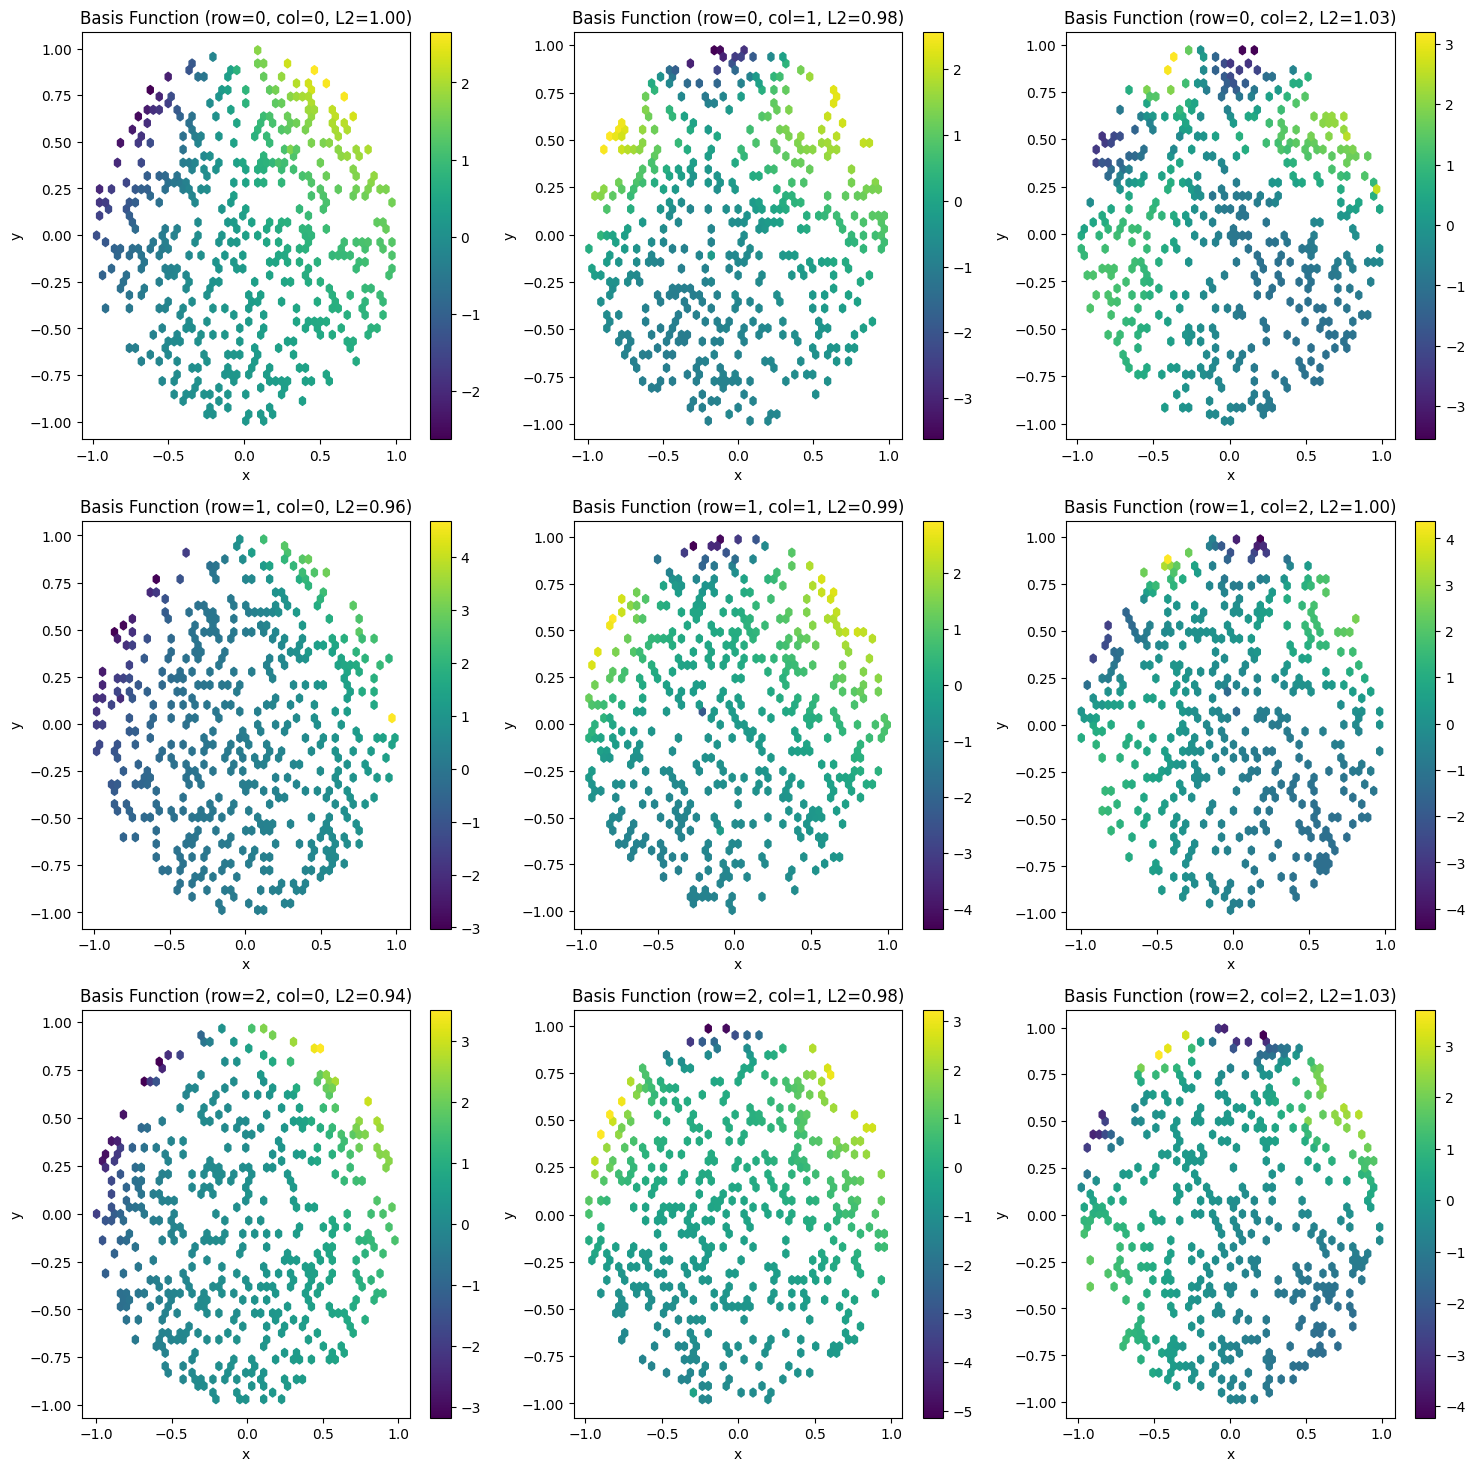

In [3]:
%autoreload 2
from half_densities.utils import radial_basis, polar_to_cartesian, sample_uniform_disk
import functools

# seed everything for reproducibility
torch.manual_seed(0)
N = 500
end_time = 5.5
all_deformed_vals = []
all_original_vals = []
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18,18))
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        basis_func = functools.partial(radial_basis, n=row+1, m=col+1, indicator=0)
        rtheta = sample_uniform_disk(N).to(device)
        xy = polar_to_cartesian(rtheta)
        all_original_vals.append(
            basis_func(xy).detach().cpu().numpy()
        )
        deformed_vals = T.evaluate(
            xy,
            start_time=0.0,
            end_time=end_time,
            initial_basis_fn=basis_func,
            n_steps=500,
        )
        all_deformed_vals.append(deformed_vals.detach().cpu().numpy())
        # approximate integral by monte carlo
        integr = torch.sqrt((deformed_vals * deformed_vals).mean()).item()  # should be close to zero
        # clamp deformed_vals for better visualization
        deformed_vals = torch.clamp(deformed_vals, -viz_magnitude, viz_magnitude)
        # plot deformed_vals as hexbin
        ax.hexbin(xy[:,0].detach().cpu(), xy[:,1].detach().cpu(), C=deformed_vals.detach().cpu(), gridsize=50, cmap='viridis') 
        # add a colorbar
        plt.colorbar(mappable=ax.collections[0], ax=ax)
        ax.set_title(f'Basis Function (row={row}, col={col}, L2={integr:.2f})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()

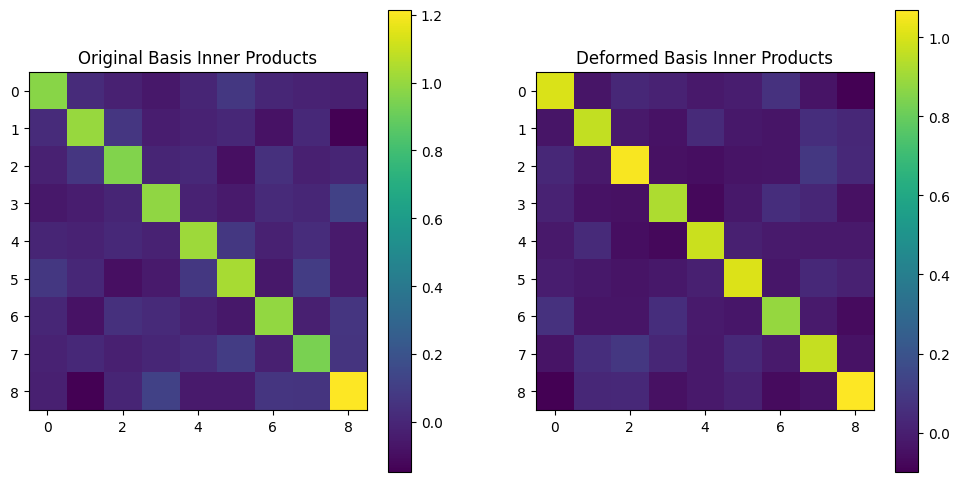

In [4]:
inner_products_defomed = np.zeros((9, 9))
inner_products_original = np.zeros((9, 9))
for i in range(len(all_deformed_vals)):
    for j in range(len(all_deformed_vals)):
        inner_products_defomed[i, j] = (all_deformed_vals[i] * all_deformed_vals[j]).mean()
        inner_products_original[i, j] = (all_original_vals[i] * all_original_vals[j]).mean()

# clamp inner products between 0 and 1
# inner_products_original = np.clip(inner_products_original, 0.0, 1.0)
# inner_products_defomed = np.clip(inner_products_defomed, 0.0, 1.0)

# plot two heatmaps side by side
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
im0 = axes[0].imshow(inner_products_original, cmap='viridis')
axes[0].set_title('Original Basis Inner Products')
fig.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(inner_products_defomed, cmap='viridis')
axes[1].set_title('Deformed Basis Inner Products')
# set the minimum of the colorbar to 0
fig.colorbar(im1, ax=axes[1])
plt.show()

## Train a Model

In [ ]:
%autoreload 2
from half_densities.utils import radial_basis, polar_to_cartesian, sample_uniform_disk
from tqdm import tqdm
import functools

N = 500
T = CTRadialFlow(
    dimensions=2,
    gamma = 1.,
    # normalize_velocity=True,
).to(device)
optimizer = torch.optim.Adam(T.parameters(), lr=1e-4)
epochs = 1000
freq_viz = 1000_0
smoothed_loss = None
loss_history = []
n_range = (2, 3)
m_range = (3, 4)
xy = polar_to_cartesian(sample_uniform_disk(N).to(device))
pbar = tqdm(range(epochs))
for idx in pbar:
    n_sampled = torch.randint(n_range[0], n_range[1], (1,)).item()
    m_sampled = torch.randint(m_range[0], m_range[1], (1,)).item()
    vals = radial_basis(xy, n=n_sampled, m=m_sampled, indicator=0)
    vals = torch.sqrt(vals ** 2 + 1e-6)
    # sample n from a geometric
    n = torch.randint(2, 3, (1,)).item()
    m = torch.randint(3, 4, (1,)).item()
    basis_func = functools.partial(radial_basis, n=row+1, m=col+1, indicator=0)
    deformed_vals = T.evaluate(
        xy,
        start_time=0.0,
        end_time=end_time,
        initial_basis_fn=basis_func,
        n_steps=1000,
    )
    # now iterate over all of the deformed basis functions and maximize their squared inner products with vals
    optimizer.zero_grad()
    loss = 0.0
    loss -= (deformed_vals * vals).mean() ** 2
    loss.backward()
    smoothed_loss = loss.item() if smoothed_loss is None else 0.9 * smoothed_loss + 0.1 * loss.item()
    # compute the magnitude of the gradient
    print_grad = 0.0
    for param in T.parameters():
        if param.grad is not None:
            print_grad += param.grad.norm().item()
    pbar.set_postfix({'loss': smoothed_loss})
    optimizer.step()
    # loss_history.append(loss.item())
    # if (idx + 1) % freq_viz == 0:
    #     fig, axes = plt.subplots(figsize=(6 * 3,5 * 3), nrows=3, ncols=3)
    #     for row in range(3):
    #         for col in range(3):
    #             ax = axes[row, col]
    #             xy = torch.rand(N, 2).to(device)
    #             vals = deformed_basis(xy, transform=T, basis_fn=fourier_basis_2d, kx=row + 1, ky=col + 1).detach()
    #             ax.hexbin(xy.detach().cpu()[:,0], xy.detach().cpu()[:,1], C=vals.detach().cpu(), gridsize=50, cmap='viridis') 
    #             ax.set_title(f'Deformed Function (row={row}, col={col})')
    #             ax.set_xlabel('x')
    #             ax.set_ylabel('y')
    #     plt.show()
    

  0%|          | 0/1000 [00:00<?, ?it/s]

 10%|█         | 102/1000 [05:26<47:57,  3.20s/it, loss=-0.0474]


KeyboardInterrupt: 